
# วิธีการก่อกวนตัวแปรเดียว

ระดับกลาง ensemble inference โดยใช้วิธีการก่อกวนที่กำหนดเอง

ตัวอย่างนี้จะสาธิตวิธีการรัน ensemble inference workflow
ด้วยวิธีก่อกวนแบบกำหนดเองที่ใช้เฉพาะเสียงรบกวนกับตัวแปรเฉพาะเท่านั้น

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีขยายวิธีการก่อกวนที่มีอยู่
- วิธีสร้างอินสแตนซ์ของโมเดลพยากรณ์ที่มีมาให้ในระบบ
- วิธีสร้างแหล่งข้อมูลและออบเจ็กต์ IO
- วิธีรัน workflow พื้นฐานที่มีมาให้ในระบบ
- ขยายวิธีการในตัวโดยใช้โค้ดที่กำหนดเอง
- วิธีทำ post-processing กับผลลัพธ์


In [ ]:
# /// script
# dependencies = [
#   "torch==2.9.1", # Match lock file to avoid torch-harmonics issue
#   "earth2studio[dlwp,perturbation] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "matplotlib",
# ]
# ///

## การเตรียมองค์ประกอบ
workflow ทุกตัวภายใน Earth2Studio จำเป็นต้องได้รับคอมโพเนนต์ที่สร้างไว้ล่วงหน้า
แล้วส่งเข้าไปให้ใช้งาน ในตัวอย่างนี้ เราจะใช้ ensemble workflow ในตัว
:py:meth:`earth2studio.run.ensemble`.



.. literalinclude:: ../../earth2studio/run.py
   :language: python
   :start-after: # sphinx - ensemble start
   :end-before: # sphinx - ensemble end



เราจำเป็นต้องมีองค์ประกอบต่อไปนี้:

- Prognostic Model: ใช้ DLWP รุ่น :py:class:`earth2studio.models.px.DLWP` ในตัว
- perturbation_method: ขยายวิธี Spherical Gaussian :py:class:`earth2studio.perturbation.SphericalGaussian`
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกเอาต์พุตลงในร้านค้า Zarr :py:class:`earth2studio.io.ZarrBackend`



In [1]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

import numpy as np
import torch

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.px import DLWP
from earth2studio.perturbation import Perturbation, SphericalGaussian
from earth2studio.run import ensemble
from earth2studio.utils.type import CoordSystem

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = DLWP.load_default_package()
model = DLWP.load_model(package)

# สร้างแหล่งข้อมูล
data = GFS()

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


วิธีการก่อกวนใน `sphx_glr_examples_01_getting_started_03_ensemble_workflow.py`
ไร้เดียงสาเพราะมันใช้แอมพลิจูดของสัญญาณรบกวนเท่ากันกับทุกตัวแปร เราสามารถสร้างได้
Wrapper แบบกำหนดเองที่ใช้วิธีการก่อกวนกับตัวแปรเฉพาะเท่านั้น
แทน.



In [2]:
class ApplyToVariable:
    """Apply a perturbation to only a particular variable."""

    def __init__(self, pm: Perturbation, variable: str | list[str]):
        self.pm = pm
        if isinstance(variable, str):
            variable = [variable]
        self.variable = variable

    @torch.inference_mode()
    def __call__(
        self,
        x: torch.Tensor,
        coords: CoordSystem,
    ) -> tuple[torch.Tensor, CoordSystem]:
        # ก่อกวน
        xp, _ = self.pm(x, coords)
        # เพิ่มชิ้นที่ตกอกตกใจกลับเข้าไปในเทนเซอร์เดิม
        ind = np.isin(coords["variable"], self.variable)
        x[..., ind, :, :] = xp[..., ind, :, :]
        return x, coords


# Generate a new noise amplitude that specifically targets 't2m' with a 1 K noise amplitude
avsg = ApplyToVariable(SphericalGaussian(noise_amplitude=1.0), "t2m")

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
chunks = {"ensemble": 1, "time": 1, "lead_time": 1}
io = ZarrBackend(
    file_name="outputs/05_ensemble_avsg.zarr",
    chunks=chunks,
    backend_kwargs={"overwrite": True},
)

## การรัน Workflow
เมื่อคอมโพเนนต์ทั้งหมดเริ่มต้นแล้ว การรัน workflow จะเป็นโค้ด Python บรรทัดเดียว
เวิร์กโฟลว์จะส่งคืนอ็อบเจ็กต์ IO ที่ระบุกลับไปยังผู้ใช้ ซึ่งสามารถนำมาใช้ได้
จากนั้นจึงโพสต์กระบวนการ บางตัวมี API เพิ่มเติมซึ่งมีประโยชน์สำหรับ post-processing หรือ
บันทึกเป็นไฟล์ ตรวจสอบเอกสาร API สำหรับข้อมูลเพิ่มเติม

สำหรับการพยากรณ์ เราจะคาดการณ์ 10 ขั้นตอน (สำหรับ FCN คือ 60 ชั่วโมง) โดยมี 8 ensemble
สมาชิกที่จะวิ่งใน 2 batches กับ batch ขนาด 4



In [3]:
nsteps = 10
nensemble = 8
batch_size = 4
io = ensemble(
    ["2024-01-01"],
    nsteps,
    nensemble,
    model,
    data,
    io,
    avsg,
    batch_size=batch_size,
    output_coords={"variable": np.array(["t2m", "tcwv"])},
)

2026-04-24 13:41:42.000 | INFO     | earth2studio.run:ensemble:328 - Running ensemble inference!
2026-04-24 13:41:42.000 | INFO     | earth2studio.run:ensemble:336 - Inference device: cuda


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 101.49it/s]


2026-04-24 13:41:42.242 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 208052937-721817
2026-04-24 13:41:42.259 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 397402829-996456
2026-04-24 13:41:42.270 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 251230645-803982
2026-04-24 13:41:42.278 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 329116923-847018
2026-04-24 13:41:42.287 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 420029701-1181204
2026-04-24 13:41:42.295 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 120.96it/s]


2026-04-24 13:41:42.352 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 204118947-720169
2026-04-24 13:41:42.360 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 391722290-987401
2026-04-24 13:41:42.368 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 289307267-851916
2026-04-24 13:41:42.376 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 414179964-1179422
2026-04-24 13:41:42.383 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 246334297-805355
2026-04-24 13:41:42.392 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS




Total Ensemble Batches: 100%|██████████| 2/2 [00:05<00:00,  2.99s/it]

2026-04-24 13:41:48.428 | SUCCESS  | earth2studio.run:ensemble:439 - 
Inference complete


## การทำ Post-Processing
ขั้นตอนสุดท้ายคือการนำผลลัพธ์มาทำ post-process ต่อ ให้พล็อตทั้งฟิลด์ t2m ที่ถูกรบกวน
และสนาม tcwv ที่ไม่ถูกรบกวนด้วย ขั้นแรกให้ยืนยันวิธีการก่อกวนว่าได้ผลอย่างไร
คาดว่าสถานะเริ่มต้นจะถูกพล็อต

สังเกตว่าฟังก์ชัน Zarr IO มี API เพิ่มเติมสำหรับใช้เข้าถึงและจัดการข้อมูลที่เก็บไว้



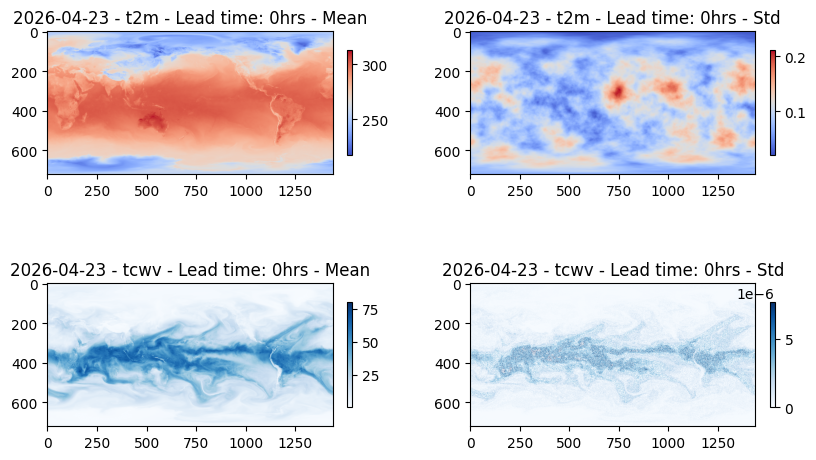

In [5]:
import matplotlib.pyplot as plt

forecast = "2026-04-23"


def plot_(axi, data, title, cmap):
    """Simple plot util function"""
    im = axi.imshow(data, cmap=cmap)
    plt.colorbar(im, ax=axi, shrink=0.5, pad=0.04)
    axi.set_title(title)


step = 0  # lead time = 24 ชม
plt.close("all")

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
plot_(
    ax[0, 0],
    np.mean(io["t2m"][:, 0, step], axis=0),
    f"{forecast} - t2m - Lead time: {6*step}hrs - Mean",
    "coolwarm",
)
plot_(
    ax[0, 1],
    np.std(io["t2m"][:, 0, step], axis=0),
    f"{forecast} - t2m - Lead time: {6*step}hrs - Std",
    "coolwarm",
)
plot_(
    ax[1, 0],
    np.mean(io["tcwv"][:, 0, step], axis=0),
    f"{forecast} - tcwv - Lead time: {6*step}hrs - Mean",
    "Blues",
)
plot_(
    ax[1, 1],
    np.std(io["tcwv"][:, 0, step], axis=0),
    f"{forecast} - tcwv - Lead time: {6*step}hrs - Std",
    "Blues",
)

plt.savefig(f"outputs/05_{forecast}_{step}_ensemble.jpg")

เนื่องจากการมีเพศสัมพันธ์ภายในระหว่างทุกฟิลด์ เราควรคาดหวังว่าตัวแปรทั้งหมดจะเป็นเช่นนั้น
มีความไม่แน่นอนสำหรับ lead time ในภายหลัง นี่คือไอน้ำรวมของคอลัมน์
พล็อตที่ lead time เป็นเวลา 24 ชั่วโมง สังเกตความแปรปรวนในสมาชิกแม้จะเพียง
รบกวนสนามอุณหภูมิ



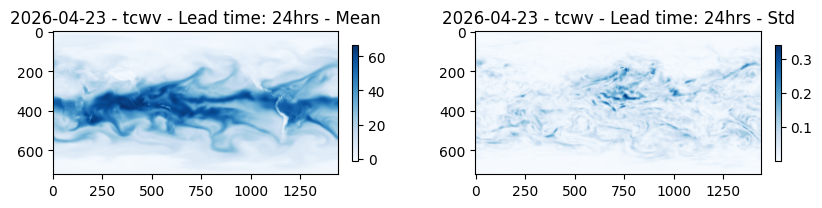

In [6]:
step = 4  # lead time = 24 ชม
plt.close("all")

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
plot_(
    ax[0],
    np.mean(io["tcwv"][:, 0, step], axis=0),
    f"{forecast} - tcwv - Lead time: {6*step}hrs - Mean",
    "Blues",
)
plot_(
    ax[1],
    np.std(io["tcwv"][:, 0, step], axis=0),
    f"{forecast} - tcwv - Lead time: {6*step}hrs - Std",
    "Blues",
)

plt.savefig(f"outputs/05_{forecast}_{step}_ensemble.jpg")